# Overview

**Objective:** Create a binary classification model to predict the likelihood of Pancytopenia.

**Overview:**
Pancytopenia is a condition that when treated in the hospital results in 1 or more of 3 codes upon discharge: D61.818, D61.810, and/or D61.811. Your task is to take the data provided, engineer features and create a machine learning model that can identify occurrences of this condition in future patients. Feel free to manipulate the data however you want to create features. You may or may not need all the data to solve the problem. Feel free to use any type of algorithm that you think may solve the problem.

The data is broken up into 3 .csv files.
1. **BasicData_Technical_Interview.csv**. This file provides a unique id for each patient, the gender, age, and the “result”. The “result” is filled in with the specific code that the patient was coded with IF the patient was coded with a Pancytopenia code.
2. **Medications_Technical_Interview.csv**. This file gives information about the medication that was used for the patients. The file includes unique ids, generic drug names (if applicable), drug categories (if applicable), actual names, the administered date, the administered amount and the administered unit.
3. **Observations_Technical_Interview.csv**. This file provides information on 11 different observations obtained from the patient and the lab values observed. The file includes unique ids, the observation date, observation amount, and the observation name.

Waystar Sr Data Scientist Take-Home Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from datetime import datetime
import re
import requests
import time

# Feature selection
from scipy.stats import pearsonr
from sklearn.feature_selection import chi2, mutual_info_classif

# Model selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict
from sklearn.metrics import roc_curve, precision_recall_curve, auc, precision_score, recall_score, f1_score

# Feature importance
import shap
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 1000)

# Import datasets

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/yessirbacon1/technical-interview-takehome/BasicData_Technical_Interview_FINAL.csv
/kaggle/input/datasets/yessirbacon1/technical-interview-takehome/Medications_Technical_Interview_FINAL.csv
/kaggle/input/datasets/yessirbacon1/technical-interview-takehome/Observations_Technical_Interview_FINAL.csv
/kaggle/input/datasets/yessirbacon1/rxnorm-mapping/rxnorm_mapping_v2.csv


## Basic data

In [3]:
# BasicData_Technical_Interview.csv. 
# This file provides a unique id for each patient, the
# gender, age, and the “result”. The “result” is filled in with the specific code that the
# patient was coded with IF the patient was coded with a Pancytopenia code.

file_path = '/kaggle/input/datasets/yessirbacon1/technical-interview-takehome/BasicData_Technical_Interview_FINAL.csv'
basic_df = pd.read_csv(file_path, index_col='Unnamed: 0')
# basic_df = pd.read_csv('BasicData_Technical_Interview_FINAL.csv', index_col='Unnamed: 0')

# Sort by visit_id
basic_df = basic_df.sort_values('visit_id').reset_index(drop=True)

print(basic_df.shape)
basic_df.head()

(10261, 4)


,visit_id,gender,age,result
0,642556,0,50.0,NaN
1,680367,0,67.0,NaN
2,1025760,0,72.0,D61.818
3,1099030,0,58.0,NaN
4,1145487,0,59.0,D61.818


In [4]:
basic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   visit_id  10261 non-null  int64  
 1   gender    10261 non-null  int64  
 2   age       10261 non-null  float64
 3   result    181 non-null    object 
dtypes: float64(1), int64(2), object(1)
memory usage: 320.8+ KB


## Medications data

In [5]:
# Medications_Technical_Interview.csv. This file gives information about the medication
# that was used for the patients. The file includes unique ids, generic drug names (if
# applicable), drug categories (if applicable), actual names, the administered date, the
# administered amount and the administered unit.

file_path = '/kaggle/input/datasets/yessirbacon1/technical-interview-takehome/Medications_Technical_Interview_FINAL.csv'
medications_df = pd.read_csv(file_path, index_col='Unnamed: 0')
# medications_df = pd.read_csv('Medications_Technical_Interview_FINAL.csv', index_col='Unnamed: 0')

medications_df['administration_date'] = pd.to_datetime(medications_df['administration_date'])

# Sort by visit_id and administration_date
medications_df = medications_df.sort_values(['visit_id', 'administration_date']).reset_index(drop=True)

print(medications_df.shape)
medications_df.head()

(318194, 7)


,visit_id,drug_generic_name,drug_category_code,give_name,administered_amount,administered_units,administration_date
0,642556,NaN,NaN,Desmopressin IVPB,40.0,mcg,2021-10-08 09:15:00
1,642556,NaN,NaN,NiCARdipine Drip 40mg in NS 200ml,25.0,ml/hr,2021-10-08 09:15:00
2,642556,NaN,NaN,fentaNYL (50mcg/ml) Injectable,0.0,NaN,2021-10-08 09:15:38
3,642556,NaN,NaN,fentaNYL Drip,2.5,ml/hr,2021-10-08 10:06:00
4,642556,NaN,NaN,Propofol Drip,3.0,ml/hr,2021-10-08 10:06:00


In [6]:
medications_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318194 entries, 0 to 318193
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   visit_id             318194 non-null  int64         
 1   drug_generic_name    174881 non-null  object        
 2   drug_category_code   41517 non-null   object        
 3   give_name            318194 non-null  object        
 4   administered_amount  318194 non-null  float64       
 5   administered_units   294873 non-null  object        
 6   administration_date  318194 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 17.0+ MB


## Observations data

In [7]:
# Observations_Technical_Interview.csv. This file provides information on 11 different
# observations obtained from the patient and the lab values observed. The file includes
# unique ids, the observation date, observation amount, and the observation name.

file_path = '/kaggle/input/datasets/yessirbacon1/technical-interview-takehome/Observations_Technical_Interview_FINAL.csv'
observations_df = pd.read_csv(file_path, index_col='Unnamed: 0')
# observations_df = pd.read_csv('Observations_Technical_Interview_FINAL.csv', index_col='Unnamed: 0')

observations_df['observation_date'] = pd.to_datetime(observations_df['observation_date'])

# Sort by visit_id and observation_date
observations_df = observations_df.sort_values(['visit_id', 'observation_date']).reset_index(drop=True)

print(observations_df.shape)
observations_df.head()

(1022704, 4)


,visit_id,value,observation,observation_date
0,642556,123.0,glucose,2021-10-08 09:08:00
1,642556,48.0,hct,2021-10-08 09:18:00
2,642556,162.0,glucose,2021-10-08 09:18:00
3,642556,143.0,sodium,2021-10-08 09:18:00
4,642556,3.7,potassium,2021-10-08 09:18:00


In [8]:
observations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1022704 entries, 0 to 1022703
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   visit_id          1022704 non-null  int64         
 1   value             1005232 non-null  float64       
 2   observation       1022704 non-null  object        
 3   observation_date  1022704 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 31.2+ MB


# Data understanding

In [9]:
# Total number of patients
print(f'Total number of patients in basic_df: {basic_df["visit_id"].nunique():,.0f}')
print(f'Total number of patients in medications_df: {medications_df["visit_id"].nunique():,.0f}')
print(f'Total number of patients in observations_df: {observations_df["visit_id"].nunique():,.0f}')
print(f'Total number of patients present in all three datasets: {len(set(basic_df["visit_id"]).intersection(set(medications_df["visit_id"])).intersection(set(observations_df["visit_id"]))):,.0f}')

Total number of patients in basic_df: 10,261
Total number of patients in medications_df: 8,629
Total number of patients in observations_df: 9,942
Total number of patients present in all three datasets: 8,629


In [10]:
def count_nulls(df):
    """Count number of missing values in each column of the dataframe and return a sorted series of columns with missing values."""
    return df.isna().sum().where(lambda x: x > 0).dropna().sort_values(ascending=False)

## Basic

In [11]:
# BasicData
basic_df.head()

,visit_id,gender,age,result
0,642556,0,50.0,NaN
1,680367,0,67.0,NaN
2,1025760,0,72.0,D61.818
3,1099030,0,58.0,NaN
4,1145487,0,59.0,D61.818


In [12]:
# Check for missing values
print("Missing values in basic_df:")
count_nulls(basic_df)

Missing values in basic_df:


result    10080.0
dtype: float64

In [13]:
# The “result” is filled in with the specific code that the
# patient was coded with IF the patient was coded with a Pancytopenia code.
print('Count of Pancytopenia codes:')
print(basic_df['result'].value_counts(dropna=False))
print('\nPercent of Pancytopenia codes:')
print(basic_df['result'].value_counts(normalize=True, dropna=False) * 100)

Count of Pancytopenia codes:
result
NaN                10080
D61.818              150
D61.810               29
D61.811                1
D61.810,D61.818        1
Name: count, dtype: int64

Percent of Pancytopenia codes:
result
NaN                98.236039
D61.818             1.461846
D61.810             0.282624
D61.811             0.009746
D61.810,D61.818     0.009746
Name: proportion, dtype: float64


In [14]:
# Create binary target variable
print('Categorize patients if they had Pancytopenia or not:')
basic_df['has_pancytopenia'] = basic_df['result'].notna().astype(int)
print(basic_df['has_pancytopenia'].value_counts())
print('')
print(basic_df['has_pancytopenia'].value_counts(normalize=True) * 100)

Categorize patients if they had Pancytopenia or not:
has_pancytopenia
0    10080
1      181
Name: count, dtype: int64

has_pancytopenia
0    98.236039
1     1.763961
Name: proportion, dtype: float64


In [15]:
# Gender distribution
    # Most patients are gender 1
basic_df['gender'].value_counts(dropna=False)

gender
1    6086
0    4175
Name: count, dtype: int64

In [16]:
# Age summary statistics
    # 18 to 80 years old
    # Average age is 55 years old
    # Median age is 60 years old
basic_df['age'].describe().astype(int)

count    10261
mean        55
std         20
min         18
25%         35
50%         60
75%         75
max         80
Name: age, dtype: int64

<Axes: >

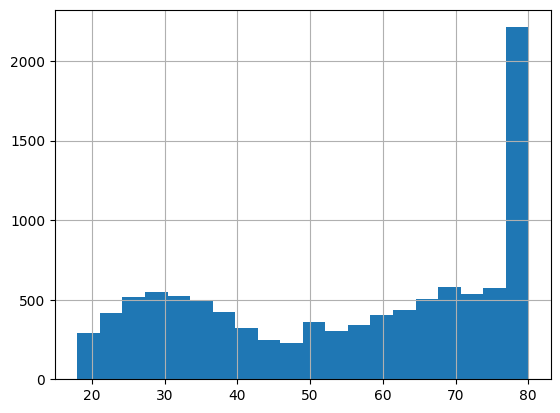

In [17]:
# Age distribution
    # Most patients are > 75 years old
basic_df['age'].hist(bins=20)

<Axes: xlabel='has_pancytopenia', ylabel='age'>

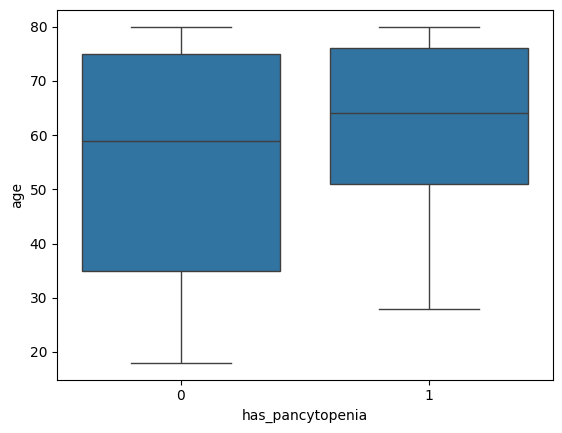

In [18]:
# Age distribution by Pancytopenia status
    # Patients with Pancytopenia tend to be older
sns.boxplot(data=basic_df, x='has_pancytopenia', y='age')

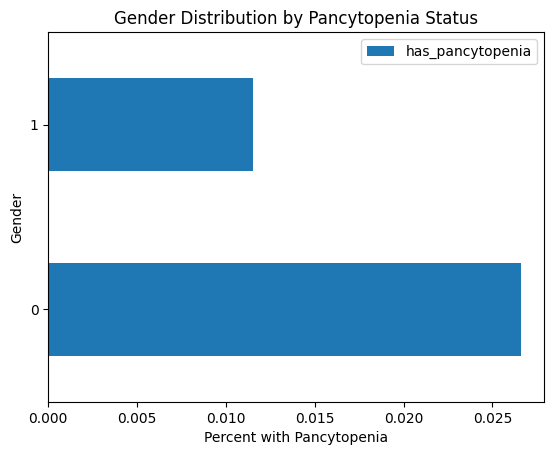

In [19]:
# Gender distribution by Pancytopenia status
    # Pancytopenia is more common in gender 0
basic_df.groupby('gender').agg({'has_pancytopenia': 'mean'}).plot(kind='barh')
plt.title('Gender Distribution by Pancytopenia Status')
plt.xlabel('Percent with Pancytopenia')
plt.ylabel('Gender')
plt.show()

In [20]:
# Average age by gender and Pancytopenia status
    # Gender 0 with Pancytopenia tend to be younger (average age is 60 years old)
    # Gender 1 with Pancytopenia tend to be older (average age is 65 years old)
basic_df.pivot_table(index='gender', columns='has_pancytopenia', values='age', aggfunc='mean')

has_pancytopenia,0,1
gender,,
0,61.215305,60.270270
1,50.980884,65.114286


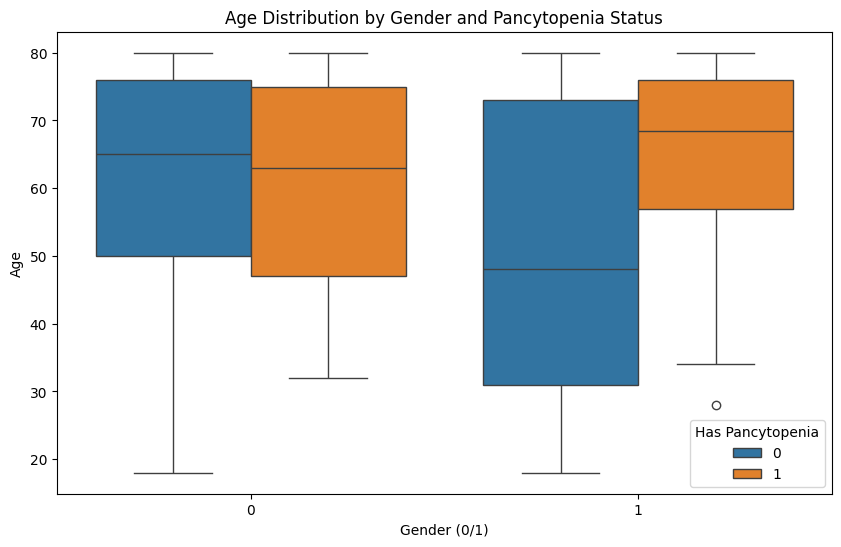

In [21]:
# Age distribution for each combination of gender and Pancytopenia status
plt.figure(figsize=(10, 6))
sns.boxplot(data=basic_df, x='gender', y='age', hue='has_pancytopenia')
plt.title('Age Distribution by Gender and Pancytopenia Status')
plt.xlabel('Gender (0/1)')
plt.ylabel('Age')
plt.legend(title='Has Pancytopenia')
plt.show()

## Medications

In [22]:
# Medications
medications_df.head()

,visit_id,drug_generic_name,drug_category_code,give_name,administered_amount,administered_units,administration_date
0,642556,NaN,NaN,Desmopressin IVPB,40.0,mcg,2021-10-08 09:15:00
1,642556,NaN,NaN,NiCARdipine Drip 40mg in NS 200ml,25.0,ml/hr,2021-10-08 09:15:00
2,642556,NaN,NaN,fentaNYL (50mcg/ml) Injectable,0.0,NaN,2021-10-08 09:15:38
3,642556,NaN,NaN,fentaNYL Drip,2.5,ml/hr,2021-10-08 10:06:00
4,642556,NaN,NaN,Propofol Drip,3.0,ml/hr,2021-10-08 10:06:00


In [23]:
# Check for missing values
print("Missing values in medications_df:")
count_nulls(medications_df)

Missing values in medications_df:


drug_category_code    276677.0
drug_generic_name     143313.0
administered_units     23321.0
dtype: float64

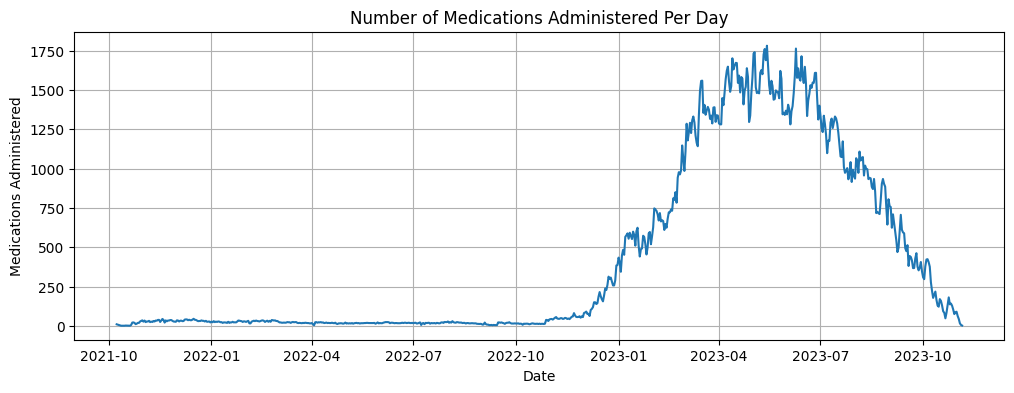

In [24]:
# Number of medications administered per day
medications_per_day = (
    medications_df
    .query('administration_date >= "2021-01-01" ')
    .groupby(medications_df['administration_date'].dt.date)
    .agg({'give_name': 'count'})
    .rename(columns={'give_name': 'medications_administered'})
)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(medications_per_day)
plt.grid(True)
plt.title('Number of Medications Administered Per Day')
plt.xlabel('Date')
plt.ylabel('Medications Administered')
plt.show()

In [25]:
# Most common medications (drug_generic_name)
print('Most common medications (drug_generic_name):')
medications_df['drug_generic_name'].value_counts(dropna=False).head(10)

Most common medications (drug_generic_name):


drug_generic_name
NaN                      143313
heparin                   22926
insulin                   12672
lactatedRingers            8633
pantoprazole               8550
folicAcid                  8060
metoprolol                 5831
albuterol/ipratropium      5624
morphine                   4386
potassiumChloride          4206
Name: count, dtype: int64

In [26]:
# Most common medications (drug_category_code)
print('Most common medications (drug_category_code):')
medications_df['drug_category_code'].value_counts(dropna=False).head(10)

Most common medications (drug_category_code):


drug_category_code
NaN               276677
anticoagulant      14599
antibiotic          7129
ivFluid             5065
ferrous             3090
betaBlocker         2106
bronchodilator      1956
anticonvulsant      1664
opioid              1481
corticosteroid      1165
Name: count, dtype: int64

In [27]:
# Most common administered units
print('Most common administered units:')
medications_df['administered_units'].value_counts(dropna=False).head(10)

Most common administered units:


administered_units
mg                162970
ml/hr              45523
unit(s)            32252
NaN                23321
ml                 13663
tablet(s)          10701
application(s)      6290
gm                  6079
mcg                 5067
drop(s)             4270
Name: count, dtype: int64

In [28]:
# Most common medications (give_name)
print('Most common medications (give_name):')
medications_df['give_name'].value_counts(dropna=False).head(10)

Most common medications (give_name):


give_name
heparin (5000 units/mL) Injectable Solution 1ml(Heparin Sodium 5000 units/mL SOL    13276
Acetaminophen                                                                       10013
docusate 100 mg Capsule(DOK sodium 100 mg CAP Major Pharmaceuticals Inc)             9684
Heparin (5,000 units/ml) SubCutaneous                                                9318
ibuprofen 400 mg Tablet(Ibuprofen 400 mg TAB Ascend Therapeutics)                    7093
multivitamin, prenatal with folic acid Tablet(Prenatal Elite Prenatal Multivitam     5549
acetaminophen 325 mg Tablet(Tylenol Caplet 325 mg TAB Johnson and Johnson/Merck      5356
Insulin Lispro Correction Scale Injectable                                           4875
Magnesium Sulfate 1gm In D5W 100ml                                                   4546
Albuterol + IPRAtropium Nebulizer Unit Dose                                          4399
Name: count, dtype: int64

## Clean medications give_name

In [29]:
STOP_WORDS = {
    "subcutaneous", "injectable", "infusion", "ivpb",
    "prandial", "solution", "tablet", "capsule",
    "chewable", "enteric", "coated", "unit", "dose",
    "powder", "sol", "soln", "drt", 'pharma', 'inhalation', 'app', 'inhaler', 'drip',
    'peds', 'rectal',' caplet', 'cap', 'tab', 'drips', 'phar', 'ert', 'suppository', 
    'supp', 'ointment', 'gram', 'injection', 'ointment', 'topical', 'spray', 'mucosal', 'inc', 'lozenge', 'gel',
    "immediate", "extended", "release", "er", "xr", "dr", "cr", "ns", "d5w", "water", "for", "in", "with", "and"
}

def clean_med_name(text):
    if pd.isna(text):
        return None
    
    text = text.lower()
    
    # remove parentheses
    text = re.sub(r"\(.*?\)", " ", text)
    
    # remove dosage
    text = re.sub(r"\b\d+(\.\d+)?\s?(mg|ml|units?|gm|mcg|%)\b", "", text)
    text = re.sub(r"\b\d+\b", "", text)
    
    # remove punctuation except +
    text = re.sub(r"[^\w\s+]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    parts = re.split(r"\s*\+\s*", text)
    cleaned_parts = []
    
    for part in parts:
        words = part.split()
        
        # remove unwanted tokens
        words = [
            w for w in words
            if w not in STOP_WORDS
            and len(w) > 2
        ]
        
        # dedupe
        seen = set()
        deduped = []
        for w in words:
            if w not in seen:
                seen.add(w)
                deduped.append(w)
        
        # If still too long, truncate to first 3 meaningful words
        if len(deduped) > 3:
            deduped = deduped[:3]
        
        if deduped:
            cleaned_parts.append(" ".join(deduped))
    
    if not cleaned_parts:
        return None
    
    return " + ".join(cleaned_parts)

In [30]:
# Test the cleaning function on a sample of give_name
sample_give_name = medications_df['give_name'].value_counts(dropna=False).head(40).index.tolist()
sample_give_name += ['Medication']

pd.DataFrame({
    'give_name': sample_give_name
    , 'clean_give_name': [clean_med_name(name) for name in sample_give_name]
})

,give_name,clean_give_name
0,heparin (5000 units/mL) Injectable Solution 1ml(Heparin Sodium 5000 units/mL SOL,heparin sodium
1,Acetaminophen,acetaminophen
2,docusate 100 mg Capsule(DOK sodium 100 mg CAP Major Pharmaceuticals Inc),docusate
3,"Heparin (5,000 units/ml) SubCutaneous",heparin
4,ibuprofen 400 mg Tablet(Ibuprofen 400 mg TAB Ascend Therapeutics),ibuprofen
5,"multivitamin, prenatal with folic acid Tablet(Prenatal Elite Prenatal Multivitam",multivitamin prenatal folic
6,acetaminophen 325 mg Tablet(Tylenol Caplet 325 mg TAB Johnson and Johnson/Merck,acetaminophen tylenol caplet
7,Insulin Lispro Correction Scale Injectable,insulin lispro correction
8,Magnesium Sulfate 1gm In D5W 100ml,magnesium sulfate
9,Albuterol + IPRAtropium Nebulizer Unit Dose,albuterol + ipratropium nebulizer


In [31]:
# Clean the give_name column
medications_df['clean_give_name'] = medications_df['give_name'].apply(clean_med_name)

# Split drug combinations by "+"
medications_df['drug_list'] = medications_df['clean_give_name'].str.split(r"\s*\+\s*")

# Explode the drug_list to have one row per drug, and strip whitespace
medications_df = medications_df.explode('drug_list')
medications_df['drug_list'] = medications_df['drug_list'].str.strip()

medications_df.head(10)

,visit_id,drug_generic_name,drug_category_code,give_name,administered_amount,administered_units,administration_date,clean_give_name,drug_list
0,642556,NaN,NaN,Desmopressin IVPB,40.0,mcg,2021-10-08 09:15:00,desmopressin,desmopressin
1,642556,NaN,NaN,NiCARdipine Drip 40mg in NS 200ml,25.0,ml/hr,2021-10-08 09:15:00,nicardipine,nicardipine
2,642556,NaN,NaN,fentaNYL (50mcg/ml) Injectable,0.0,NaN,2021-10-08 09:15:38,fentanyl,fentanyl
3,642556,NaN,NaN,fentaNYL Drip,2.5,ml/hr,2021-10-08 10:06:00,fentanyl,fentanyl
4,642556,NaN,NaN,Propofol Drip,3.0,ml/hr,2021-10-08 10:06:00,propofol,propofol
5,642556,NaN,NaN,Etomidate (2mg/ml) Injectable,30.0,mg,2021-10-08 10:49:00,etomidate,etomidate
6,642556,NaN,NaN,Rocuronium (10mg/ml) Injectable,150.0,mg,2021-10-08 10:49:00,rocuronium,rocuronium
7,642556,mannitol,NaN,Mannitol 20 % (20 Grams/100ml),100.0,gm,2021-10-08 13:00:00,mannitol,mannitol
8,642556,carvedilol,betaBlocker,carvedilol 12.5 mg Tablet(Carvedilol 12.5 mg TAB Zydus Pharmaceuticals (USA) Inc,0.0,NaN,2021-10-08 13:22:00,carvedilol,carvedilol
9,642556,NaN,NaN,amLODIPine 10 mg Tablet(AmLODIPine Besylate 10 mg TAB Major Pharmaceuticals Inc),0.0,NaN,2021-10-08 13:23:00,amlodipine,amlodipine


In [32]:
print(f"Before cleaning, unique give_name count: {medications_df['give_name'].nunique():,.0f}")
print(f"After cleaning, unique give_name count: {medications_df['drug_list'].nunique():,.0f}")

Before cleaning, unique give_name count: 1,679
After cleaning, unique give_name count: 999


## RxNorm normalization

In [33]:
BASE_URL = "https://rxnav.nlm.nih.gov/REST"

def get_rxcui_exact(drug_name):
    """Exact match search for drug name to get RxCUI"""
    
    url = f"{BASE_URL}/rxcui.json"
    try:
        r = requests.get(url, params={"name": drug_name}, timeout=10)
        if r.status_code != 200:
            return None
        
        data = r.json()
        ids = data.get("idGroup", {}).get("rxnormId")
        
        if ids:
            return ids[0]
        return None
    
    except requests.RequestException:
        return None

In [34]:
def get_rxcui_fuzzy(drug_name, score_threshold=70.0):
    url = f"{BASE_URL}/approximateTerm.json"
    
    try:
        r = requests.get(
            url,
            params={"term": drug_name, "maxEntries": 3},
            timeout=10
        )
        
        if r.status_code != 200:
            return None
        
        data = r.json()
        candidates = data.get("approximateGroup", {}).get("candidate", [])
        
        for c in candidates:
            try:
                score = float(c.get("score", 0))
            except (ValueError, TypeError):
                continue
            
            if score >= score_threshold:
                return c.get("rxcui")
        
        return None
    
    except requests.RequestException:
        return None

In [35]:
def get_rxcui(drug_name):
    """Unified RxCUI getter"""
    
    # Try exact first
    rxcui = get_rxcui_exact(drug_name)
    if rxcui:
        return rxcui
    
    # Fallback to fuzzy
    return get_rxcui_fuzzy(drug_name)

In [36]:
def get_ingredient_name(rxcui):
    """Get Ingredient from RxCUI"""
    
    url = f"{BASE_URL}/rxcui/{rxcui}/related.json"
    
    try:
        r = requests.get(url, params={"tty": "IN"}, timeout=10)
        if r.status_code != 200:
            return None
        
        data = r.json()
        groups = data.get("relatedGroup", {}).get("conceptGroup", [])
        
        for group in groups:
            if group.get("tty") == "IN":
                concepts = group.get("conceptProperties", [])
                if concepts:
                    return concepts[0]["name"].lower()
        
        return None
    
    except requests.RequestException:
        return None

In [37]:
def batch_map_drugs(drug_list, sleep_time=0.2):
    """Batch mapping with cache to avoid redundant API calls"""
    
    cache = {}
    results = []
    
    for drug in drug_list:
        cleaned = drug
        
        if cleaned in cache:
            results.append(cache[cleaned])
            continue
        
        print(f"Processing: {drug}")
        
        rxcui = None
        ingredient = None
        
        if cleaned:
            rxcui = get_rxcui(cleaned)
            
            if rxcui:
                ingredient = get_ingredient_name(rxcui)
        
        row = {
            "drug_name": drug,
            "cleaned_name": cleaned,
            "rxcui": rxcui,
            "ingredient": ingredient
        }
        
        cache[cleaned] = row
        results.append(row)
        
        time.sleep(sleep_time)  # be polite to API
    
    return pd.DataFrame(results)

In [38]:
# # List of drugs to map
# drug_list = sorted(medications_df['drug_list'].unique())
# print(f"Mapping {len(drug_list)} drugs to RxNorm...")

# # Get RxNorm mappings
# rxnorm_map = batch_map_drugs(drug_list)
# rxnorm_map.to_csv("rxnorm_mapping_v2.csv", index=False)

In [39]:
# Import the RxNorm mapping results
file_path = '/kaggle/input/datasets/yessirbacon1/rxnorm-mapping/rxnorm_mapping_v2.csv'
rxnorm_map = pd.read_csv(file_path)
print(rxnorm_map.shape)
rxnorm_map.head()

(999, 4)


,drug_name,cleaned_name,rxcui,ingredient
0,abacavir,abacavir,190521.0,abacavir
1,acarbose,acarbose,16681.0,acarbose
2,acetaminophen,acetaminophen,161.0,acetaminophen
3,acetaminophen butalbital caffeine,acetaminophen butalbital caffeine,NaN,NaN
4,acetaminophen codeine phosphate,acetaminophen codeine phosphate,NaN,NaN


In [40]:
# Left join the RxNorm mapping back to medications_df
medications_df = medications_df.merge(
    rxnorm_map[['drug_name', 'ingredient', 'rxcui']]
    , left_on='drug_list'
    , right_on='drug_name'
    , how='left'
)
print(medications_df.shape)
medications_df.head()

(332202, 12)


,visit_id,drug_generic_name,drug_category_code,give_name,administered_amount,administered_units,administration_date,clean_give_name,drug_list,drug_name,ingredient,rxcui
0,642556,NaN,NaN,Desmopressin IVPB,40.0,mcg,2021-10-08 09:15:00,desmopressin,desmopressin,desmopressin,desmopressin,3251.0
1,642556,NaN,NaN,NiCARdipine Drip 40mg in NS 200ml,25.0,ml/hr,2021-10-08 09:15:00,nicardipine,nicardipine,nicardipine,nicardipine,7396.0
2,642556,NaN,NaN,fentaNYL (50mcg/ml) Injectable,0.0,NaN,2021-10-08 09:15:38,fentanyl,fentanyl,fentanyl,fentanyl,4337.0
3,642556,NaN,NaN,fentaNYL Drip,2.5,ml/hr,2021-10-08 10:06:00,fentanyl,fentanyl,fentanyl,fentanyl,4337.0
4,642556,NaN,NaN,Propofol Drip,3.0,ml/hr,2021-10-08 10:06:00,propofol,propofol,propofol,propofol,8782.0


In [41]:
print(f"Started with {medications_df['give_name'].nunique():,.0f} unique drug names (give_name)")
print(f"After cleaning, there are {medications_df['drug_list'].nunique():,.0f} unique cleaned drug names (drug_list)")
print(f"Then RXNorm mapping resulted in {medications_df['ingredient'].nunique():,.0f} unique ingredients (ingredient)")
print(f"And {medications_df['rxcui'].nunique():,.0f} unique RxCUIs (rxcui)")

Started with 1,679 unique drug names (give_name)
After cleaning, there are 999 unique cleaned drug names (drug_list)
Then RXNorm mapping resulted in 506 unique ingredients (ingredient)
And 568 unique RxCUIs (rxcui)


In [42]:
# Example of ingredient with multiple RXCUIs
medications_df.query('ingredient == "dexamethasone"')[['drug_name', 'ingredient', 'rxcui']].drop_duplicates()

,drug_name,ingredient,rxcui
12768,dexamethasone,dexamethasone,3264.0
36745,dexamethasone sodium phosphate,dexamethasone,48933.0
72195,dexamethasone ophthalmic,dexamethasone,1154533.0
104287,dexamethasone otic,dexamethasone,1154536.0


In [43]:
# Most common ingredients
print('Most common ingredients:')
medications_df['ingredient'].value_counts(dropna=False).head(15)

Most common ingredients:


ingredient
NaN                  87622
heparin              22924
docusate             13197
acetaminophen        11907
ibuprofen             7909
albuterol             5970
insulin lispro        5486
atorvastatin          5434
pantoprazole          5182
sodium chloride       5158
magnesium sulfate     4547
metoprolol            4543
gabapentin            4017
morphine              3908
ceftriaxone           3827
Name: count, dtype: int64

## Observations

In [44]:
# Observations data
print(observations_df.shape)
observations_df.head()

(1022704, 4)


,visit_id,value,observation,observation_date
0,642556,123.0,glucose,2021-10-08 09:08:00
1,642556,48.0,hct,2021-10-08 09:18:00
2,642556,162.0,glucose,2021-10-08 09:18:00
3,642556,143.0,sodium,2021-10-08 09:18:00
4,642556,3.7,potassium,2021-10-08 09:18:00


In [45]:
# Check for missing values
print("Missing values in observations_df:")
print(count_nulls(observations_df))

Missing values in observations_df:
value    17472.0
dtype: float64


In [46]:
# Value summary statistics
observations_df['value'].describe().to_frame('value').style.format("{:,.2f}")

,value
count,"1,005,232.00"
mean,70.90
std,92.30
min,0.00
25%,5.60
50%,22.90
75%,133.00
max,"2,581.00"


In [47]:
# Most common observations (observation)
print(f"{observations_df['observation'].nunique()} unique observation names.")
print("Most common observation names:")
observations_df['observation'].value_counts(dropna=False).head(15)

11 unique observation names.
Most common observation names:


observation
glucose        209830
hct            100788
potassium       93682
sodium          93670
plateletNum     81417
creatinine      80394
hgb             75447
wbcNum          75033
rbcNum          75033
calcium         68726
bun             68684
Name: count, dtype: int64

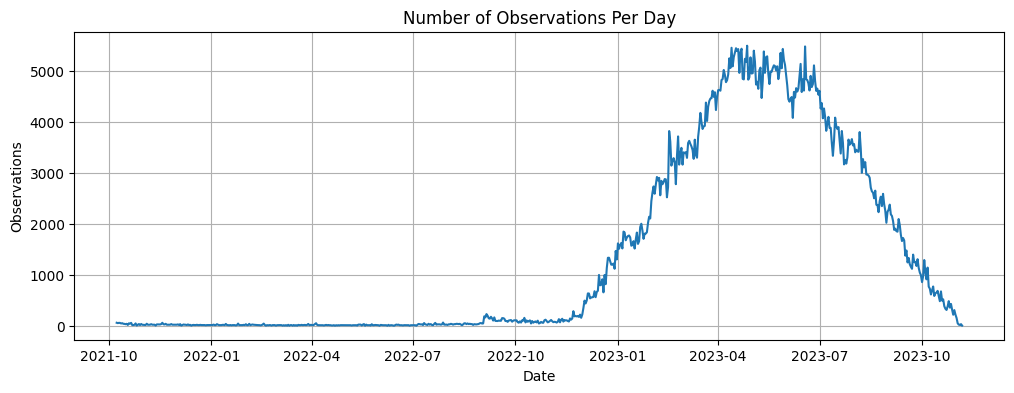

In [48]:
# Number of observations per day
observations_per_day = (
    observations_df
    .groupby(observations_df['observation_date'].dt.date)
    .agg({'observation': 'count'})
    .rename(columns={'observation': 'observations'})
)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(observations_per_day)
plt.grid(True)
plt.title('Number of Observations Per Day')
plt.xlabel('Date')
plt.ylabel('Observations')
plt.show()

# Feature engineering

## Medications features

In [49]:
# Use the first 3 days of medications per patient
    # Since I don't know when the Pancytopenia diagnosis was made, I'll use the first 3 days of medication history as a proxy for the pre-diagnosis period. 
    # This way, I can capture the medications that were likely given around the time of diagnosis, which may be more relevant for predicting Pancytopenia.
    # Assuming Pancytopenia develops over time, so early medications may be more predictive than later ones that are given after diagnosis.
    # Reduces risk of data leakage -- medications given after diagnosis or as a result of diagnosis.
    # Including post-diagnosis data will artificially inflate model performance.
med_first_dates = (
    medications_df
    .assign(administration_date_date=medications_df['administration_date'].dt.date)
    .groupby('visit_id')
    .agg({'administration_date_date': 'min'})
    .rename(columns={'administration_date_date': 'first_med_date'})
    .assign(three_days_after=lambda x: x['first_med_date'] + pd.Timedelta(days=3))
)
print(med_first_dates.shape)
med_first_dates.head()

(8629, 2)


,first_med_date,three_days_after
visit_id,,
642556,2021-10-08,2021-10-11
1025760,2022-07-06,2022-07-09
1099030,2022-09-19,2022-09-22
1145487,2022-09-03,2022-09-06
1170497,2022-12-14,2022-12-17


In [50]:
# Merge cutoff dates back to medications_df
medications_early = medications_df.merge(med_first_dates, on='visit_id', how='left')

# Keep only medications within first 3 days
medications_early = medications_early[
    medications_early['administration_date'] <= medications_early['three_days_after']
]

# Pivot to patient-level features:
    # Create binary features for each medication ingredient indicating whether the patient received that ingredient in the first 3 days.
    # Only including early medications to avoid data leakage and capture relevant pre-diagnosis medication history.
    # Use the ingredient level from RxNorm for pivoting since it's more standardized and clinically meaningful than the raw drug names.
    # Fill missing values with 'unknown' to retain those patients in the pivot (instead of dropping them), since having no ingredient information is still informative.
medication_column_to_pivot = 'ingredient'
medication_features = (
    medications_early
    .assign(one=1)
    .fillna({medication_column_to_pivot: 'unknown'})
    .pivot_table(
        index='visit_id'
        , columns=medication_column_to_pivot
        , values='one'
        , aggfunc='max'
        , fill_value=0
    )
)
print(medication_features.shape)
medication_features.head()

(8629, 480)


ingredient,abacavir,acarbose,acetaminophen,acetazolamide,acetylcysteine,acyclovir,adenosine,albuterol,alfuzosin,allopurinol,alprazolam,alteplase,aluminum hydroxide,alvimopan,amantadine,amikacin,amiodarone,amitriptyline,amlodipine,amoxicillin,amphotericin b,ampicillin,anastrozole,apixaban,aprepitant,arformoterol,aripiprazole,ascorbic acid,aspirin,atenolol,atorvastatin,atovaquone,atropine,avibactam,azathioprine,azelastine,azithromycin,aztreonam,bacitracin,baclofen,benazepril,benzocaine,benzonatate,benztropine,betamethasone,betaxolol,bicalutamide,bictegravir,bisacodyl,bisoprolol,...,terazosin,terbutaline,tetracaine,tetracycline,thiamine,thiosulfate,thyroid (usp),ticagrelor,timolol,tizanidine,tobramycin,tolterodine,topiramate,torsemide,tramadol,tranexamic acid,trazodone,tretinoin,triamcinolone,triamterene,trifluoperazine,trifluridine,trihexyphenidyl,trimethoprim,tropicamide,trospium,ubidecarenone,umeclidinium,unknown,ursodeoxycholate,vaborbactam,valacyclovir,valproate,valsartan,vancomycin,vasopressin (usp),venlafaxine,verapamil,vilanterol,vitamin b12,vitamin k1,voriconazole,vortioxetine,warfarin,zinc oxide,zinc sulfate,ziprasidone,zoledronic acid,zolpidem,zonisamide
visit_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
642556,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1025760,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1099030,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1145487,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1170497,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Observations features

In [51]:
# Use the first 3 days of observations per patient
obs_first_dates = (
    observations_df
    .assign(observation_date_date=observations_df['observation_date'].dt.date)
    .groupby('visit_id')
    .agg({'observation_date_date': 'min'})
    .rename(columns={'observation_date_date': 'first_obs_date'})
    .assign(three_days_after=lambda x: x['first_obs_date'] + pd.Timedelta(days=3))
)
print(obs_first_dates.shape)
obs_first_dates.head()

(9942, 2)


,first_obs_date,three_days_after
visit_id,,
642556,2021-10-08,2021-10-11
680367,2023-03-29,2023-04-01
1025760,2022-07-06,2022-07-09
1099030,2022-09-04,2022-09-07
1145487,2022-09-03,2022-09-06


In [52]:
# Merge cutoff dates back to observations_df
observations_early = observations_df.merge(obs_first_dates, on='visit_id', how='left')

# Keep only observations within first 3 days
observations_early = observations_early[
    observations_early['observation_date'] <= observations_early['three_days_after']
]

# Pivot to patient-level features using only early observations
observation_features = (
    observations_early
    .pivot_table(
        index='visit_id'
        , columns='observation'
        , values='value'
    )
)
print(observation_features.shape)
observation_features.head()

(9942, 11)


observation,bun,calcium,creatinine,glucose,hct,hgb,plateletNum,potassium,rbcNum,sodium,wbcNum
visit_id,,,,,,,,,,,
642556,46.229444,8.411111,3.168421,126.185185,37.792308,12.200000,228.800000,4.984000,4.164000,144.750000,18.880000
680367,23.050000,7.450000,1.300000,232.285714,36.380000,11.650000,108.500000,4.380000,3.660000,140.800000,7.950000
1025760,47.833333,8.100000,0.850000,107.400000,26.483333,8.400000,107.400000,3.625000,2.778000,144.250000,6.140000
1099030,29.669231,8.046154,2.160000,263.785714,39.268750,12.888889,212.888889,3.768571,4.580000,148.583333,20.844444
1145487,44.555556,8.222222,3.121739,198.454545,40.138710,11.993750,90.000000,5.720690,4.353125,135.151515,10.831250


In [53]:
# Percent of missing values in patient-level observation features
null_percentages = (observation_features.isnull().sum() / len(observation_features)) * 100
print(null_percentages.sort_values(ascending=False))

observation
bun            18.889559
potassium      18.869443
sodium         18.869443
calcium        18.829209
creatinine     18.738684
glucose        15.741300
plateletNum     1.629451
rbcNum          1.498692
hgb             1.498692
wbcNum          1.498692
hct             1.468517
dtype: float64


In [54]:
# New DataFrame for engineered observations features
observation_features_engineered = pd.DataFrame(index=observation_features.index)

# Separate high-completion vs high-missingness features
high_completion_cols = ['plateletNum', 'hgb', 'rbcNum', 'wbcNum', 'hct']
high_missing_cols = ['bun', 'potassium', 'sodium', 'calcium', 'creatinine', 'glucose']

# High-completion features
    # Fill nulls with median
    # Create separate binary missingness indicators since missingness itself may be informative 
    # (e.g. test not ordered because clinician didn't suspect an issue, or patient was too unstable for labs).
for col in high_completion_cols:
    observation_features_engineered[f'{col}_value'] = observation_features[col].fillna(observation_features[col].median())
    observation_features_engineered[f'{col}_missing'] = observation_features[col].isnull().astype(int)

# High-missingness features
    # Create binary presence indicators since the fact that a test was ordered (regardless of result) may be more informative than the actual value, given the high missingness.
for col in high_missing_cols:
    observation_features_engineered[f'{col}_ordered'] = observation_features[col].notnull().astype(int)

In [55]:
# Calculate the normal ranges for observations
# Then, create abnormal flags when values are outside the normal range. 
# This can help capture clinically meaningful signals that may be lost if we just use raw values, especially since different observations have different scales and units.

normal_ranges = {}
for col in observation_features:

    # Calculate normal range using 5th and 95th percentiles to be robust to outliers, since we don't have domain knowledge of the expected ranges for these observations.
    normal_ranges[col] = (
        observation_features[col]
        .dropna()
        .quantile([0.05, 0.95])
        .rename(index={0.05: 'lower_bound', 0.95: 'upper_bound'})
        .to_dict()
    )

    # Create abnormal flags
    observation_features_engineered[f'{col}_abnormal_lower'] = (observation_features[col] < normal_ranges[col]['lower_bound']).astype(int)
    observation_features_engineered[f'{col}_abnormal_upper'] = (observation_features[col] > normal_ranges[col]['upper_bound']).astype(int)

print(observation_features_engineered.shape)
observation_features_engineered.head()

(9942, 38)


,plateletNum_value,plateletNum_missing,hgb_value,hgb_missing,rbcNum_value,rbcNum_missing,wbcNum_value,wbcNum_missing,hct_value,hct_missing,bun_ordered,potassium_ordered,sodium_ordered,calcium_ordered,creatinine_ordered,glucose_ordered,bun_abnormal_lower,bun_abnormal_upper,calcium_abnormal_lower,calcium_abnormal_upper,creatinine_abnormal_lower,creatinine_abnormal_upper,glucose_abnormal_lower,glucose_abnormal_upper,hct_abnormal_lower,hct_abnormal_upper,hgb_abnormal_lower,hgb_abnormal_upper,plateletNum_abnormal_lower,plateletNum_abnormal_upper,potassium_abnormal_lower,potassium_abnormal_upper,rbcNum_abnormal_lower,rbcNum_abnormal_upper,sodium_abnormal_lower,sodium_abnormal_upper,wbcNum_abnormal_lower,wbcNum_abnormal_upper
visit_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
642556,228.800000,0,12.200000,0,4.164000,0,18.880000,0,37.792308,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
680367,108.500000,0,11.650000,0,3.660000,0,7.950000,0,36.380000,0,1,1,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1025760,107.400000,0,8.400000,0,2.778000,0,6.140000,0,26.483333,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1099030,212.888889,0,12.888889,0,4.580000,0,20.844444,0,39.268750,0,1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1145487,90.000000,0,11.993750,0,4.353125,0,10.831250,0,40.138710,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0


In [56]:
# Check for missing values in engineered observation features
count_nulls(observation_features_engineered)

Series([], dtype: float64)

## Join features and target

In [57]:
print('basic_df:', basic_df.shape)
display(basic_df.head())
print('\nmedication_features:', medication_features.shape)
display(medication_features.head())
print('\nobservation_features_engineered:', observation_features_engineered.shape)
display(observation_features_engineered.head())

basic_df: (10261, 5)


,visit_id,gender,age,result,has_pancytopenia
0,642556,0,50.0,NaN,0
1,680367,0,67.0,NaN,0
2,1025760,0,72.0,D61.818,1
3,1099030,0,58.0,NaN,0
4,1145487,0,59.0,D61.818,1



medication_features: (8629, 480)


ingredient,abacavir,acarbose,acetaminophen,acetazolamide,acetylcysteine,acyclovir,adenosine,albuterol,alfuzosin,allopurinol,alprazolam,alteplase,aluminum hydroxide,alvimopan,amantadine,amikacin,amiodarone,amitriptyline,amlodipine,amoxicillin,amphotericin b,ampicillin,anastrozole,apixaban,aprepitant,arformoterol,aripiprazole,ascorbic acid,aspirin,atenolol,atorvastatin,atovaquone,atropine,avibactam,azathioprine,azelastine,azithromycin,aztreonam,bacitracin,baclofen,benazepril,benzocaine,benzonatate,benztropine,betamethasone,betaxolol,bicalutamide,bictegravir,bisacodyl,bisoprolol,...,terazosin,terbutaline,tetracaine,tetracycline,thiamine,thiosulfate,thyroid (usp),ticagrelor,timolol,tizanidine,tobramycin,tolterodine,topiramate,torsemide,tramadol,tranexamic acid,trazodone,tretinoin,triamcinolone,triamterene,trifluoperazine,trifluridine,trihexyphenidyl,trimethoprim,tropicamide,trospium,ubidecarenone,umeclidinium,unknown,ursodeoxycholate,vaborbactam,valacyclovir,valproate,valsartan,vancomycin,vasopressin (usp),venlafaxine,verapamil,vilanterol,vitamin b12,vitamin k1,voriconazole,vortioxetine,warfarin,zinc oxide,zinc sulfate,ziprasidone,zoledronic acid,zolpidem,zonisamide
visit_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
642556,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1025760,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1099030,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1145487,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1170497,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



observation_features_engineered: (9942, 38)


,plateletNum_value,plateletNum_missing,hgb_value,hgb_missing,rbcNum_value,rbcNum_missing,wbcNum_value,wbcNum_missing,hct_value,hct_missing,bun_ordered,potassium_ordered,sodium_ordered,calcium_ordered,creatinine_ordered,glucose_ordered,bun_abnormal_lower,bun_abnormal_upper,calcium_abnormal_lower,calcium_abnormal_upper,creatinine_abnormal_lower,creatinine_abnormal_upper,glucose_abnormal_lower,glucose_abnormal_upper,hct_abnormal_lower,hct_abnormal_upper,hgb_abnormal_lower,hgb_abnormal_upper,plateletNum_abnormal_lower,plateletNum_abnormal_upper,potassium_abnormal_lower,potassium_abnormal_upper,rbcNum_abnormal_lower,rbcNum_abnormal_upper,sodium_abnormal_lower,sodium_abnormal_upper,wbcNum_abnormal_lower,wbcNum_abnormal_upper
visit_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
642556,228.800000,0,12.200000,0,4.164000,0,18.880000,0,37.792308,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
680367,108.500000,0,11.650000,0,3.660000,0,7.950000,0,36.380000,0,1,1,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1025760,107.400000,0,8.400000,0,2.778000,0,6.140000,0,26.483333,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1099030,212.888889,0,12.888889,0,4.580000,0,20.844444,0,39.268750,0,1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1145487,90.000000,0,11.993750,0,4.353125,0,10.831250,0,40.138710,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0


In [58]:
# Left join features to create complete patient-level dataset for modeling.
complete_df = (
    basic_df.drop(columns=['result'])
    .merge(medication_features.reset_index(), on='visit_id', how='left')
    .merge(observation_features_engineered.reset_index(), on='visit_id', how='left')
)
print(complete_df.shape)
complete_df.head()

(10261, 522)


,visit_id,gender,age,has_pancytopenia,abacavir,acarbose,acetaminophen,acetazolamide,acetylcysteine,acyclovir,adenosine,albuterol,alfuzosin,allopurinol,alprazolam,alteplase,aluminum hydroxide,alvimopan,amantadine,amikacin,amiodarone,amitriptyline,amlodipine,amoxicillin,amphotericin b,ampicillin,anastrozole,apixaban,aprepitant,arformoterol,aripiprazole,ascorbic acid,aspirin,atenolol,atorvastatin,atovaquone,atropine,avibactam,azathioprine,azelastine,azithromycin,aztreonam,bacitracin,baclofen,benazepril,benzocaine,benzonatate,benztropine,betamethasone,betaxolol,...,vilanterol,vitamin b12,vitamin k1,voriconazole,vortioxetine,warfarin,zinc oxide,zinc sulfate,ziprasidone,zoledronic acid,zolpidem,zonisamide,plateletNum_value,plateletNum_missing,hgb_value,hgb_missing,rbcNum_value,rbcNum_missing,wbcNum_value,wbcNum_missing,hct_value,hct_missing,bun_ordered,potassium_ordered,sodium_ordered,calcium_ordered,creatinine_ordered,glucose_ordered,bun_abnormal_lower,bun_abnormal_upper,calcium_abnormal_lower,calcium_abnormal_upper,creatinine_abnormal_lower,creatinine_abnormal_upper,glucose_abnormal_lower,glucose_abnormal_upper,hct_abnormal_lower,hct_abnormal_upper,hgb_abnormal_lower,hgb_abnormal_upper,plateletNum_abnormal_lower,plateletNum_abnormal_upper,potassium_abnormal_lower,potassium_abnormal_upper,rbcNum_abnormal_lower,rbcNum_abnormal_upper,sodium_abnormal_lower,sodium_abnormal_upper,wbcNum_abnormal_lower,wbcNum_abnormal_upper
0,642556,0,50.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,228.800000,0.0,12.200000,0.0,4.164000,0.0,18.880000,0.0,37.792308,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,680367,0,67.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,108.500000,0.0,11.650000,0.0,3.660000,0.0,7.950000,0.0,36.380000,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1025760,0,72.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,107.400000,0.0,8.400000,0.0,2.778000,0.0,6.140000,0.0,26.483333,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1099030,0,58.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,212.888889,0.0,12.888889,0.0,4.580000,0.0,20.844444,0.0,39.268750,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1145487,0,59.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90.000000,0.0,11.993750,0.0,4.353125,0.0,10.831250,0.0,40.138710,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
# Check for missing values in complete_df
count_nulls(complete_df)

zonisamide               1632.0
zolpidem                 1632.0
zoledronic acid          1632.0
ziprasidone              1632.0
zinc sulfate             1632.0
                          ...  
rbcNum_abnormal_upper     319.0
sodium_abnormal_lower     319.0
sodium_abnormal_upper     319.0
wbcNum_abnormal_lower     319.0
wbcNum_abnormal_upper     319.0
Length: 518, dtype: float64

In [60]:
# Fill missing values in medication features with 0 (indicating patient did not receive that medication, which is informative)
complete_df = complete_df.fillna({col: 0 for col in medication_features})

# High-completion features
    # Fill nulls with median
    # Create separate binary missingness indicators since missingness itself may be informative 
    # (e.g. test not ordered because clinician didn't suspect an issue, or patient was too unstable for labs).
for col in high_completion_cols:
    complete_df[f'{col}_value'] = complete_df[f'{col}_value'].fillna(observation_features[col].median())
    complete_df[f'{col}_missing'] = complete_df[f'{col}_missing'].fillna(1)

# High-missingness features
    # Create binary presence indicators since the fact that a test was ordered (regardless of result) may be more informative than the actual value, given the high missingness.
for col in high_missing_cols:
    complete_df[f'{col}_ordered'] = complete_df[f'{col}_ordered'].fillna(0)

# Abnormal flags for observations
    # Fill missing abnormal flags with 0, assuming that if the observation is missing, we will treat it as not abnormal. 
    # This is a simplifying assumption, but given the high missingness and the fact that we already have separate indicators for whether the test was ordered, 
    # it allows us to retain those patients in the dataset without dropping them due to missingness in the abnormal flags.
for col in complete_df:
    if '_abnormal_' in col:
        complete_df[col] = complete_df[col].fillna(0)

In [61]:
# Check for any remaining missing values
count_nulls(complete_df)

Series([], dtype: float64)

# Feature selection

In [62]:
# 520 features is too many for only 181 patients with Pancytopenia
print(complete_df.shape)
complete_df.head(3)

(10261, 522)


,visit_id,gender,age,has_pancytopenia,abacavir,acarbose,acetaminophen,acetazolamide,acetylcysteine,acyclovir,adenosine,albuterol,alfuzosin,allopurinol,alprazolam,alteplase,aluminum hydroxide,alvimopan,amantadine,amikacin,amiodarone,amitriptyline,amlodipine,amoxicillin,amphotericin b,ampicillin,anastrozole,apixaban,aprepitant,arformoterol,aripiprazole,ascorbic acid,aspirin,atenolol,atorvastatin,atovaquone,atropine,avibactam,azathioprine,azelastine,azithromycin,aztreonam,bacitracin,baclofen,benazepril,benzocaine,benzonatate,benztropine,betamethasone,betaxolol,...,vilanterol,vitamin b12,vitamin k1,voriconazole,vortioxetine,warfarin,zinc oxide,zinc sulfate,ziprasidone,zoledronic acid,zolpidem,zonisamide,plateletNum_value,plateletNum_missing,hgb_value,hgb_missing,rbcNum_value,rbcNum_missing,wbcNum_value,wbcNum_missing,hct_value,hct_missing,bun_ordered,potassium_ordered,sodium_ordered,calcium_ordered,creatinine_ordered,glucose_ordered,bun_abnormal_lower,bun_abnormal_upper,calcium_abnormal_lower,calcium_abnormal_upper,creatinine_abnormal_lower,creatinine_abnormal_upper,glucose_abnormal_lower,glucose_abnormal_upper,hct_abnormal_lower,hct_abnormal_upper,hgb_abnormal_lower,hgb_abnormal_upper,plateletNum_abnormal_lower,plateletNum_abnormal_upper,potassium_abnormal_lower,potassium_abnormal_upper,rbcNum_abnormal_lower,rbcNum_abnormal_upper,sodium_abnormal_lower,sodium_abnormal_upper,wbcNum_abnormal_lower,wbcNum_abnormal_upper
0,642556,0,50.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,228.8,0.0,12.20,0.0,4.164,0.0,18.88,0.0,37.792308,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,680367,0,67.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,108.5,0.0,11.65,0.0,3.660,0.0,7.95,0.0,36.380000,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1025760,0,72.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,107.4,0.0,8.40,0.0,2.778,0.0,6.14,0.0,26.483333,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [63]:
# Target variable distribution
complete_df['has_pancytopenia'].value_counts()

has_pancytopenia
0    10080
1      181
Name: count, dtype: int64

In [64]:
# Separate binary vs continuous features
binary_features = []
continuous_features = []

for col in complete_df:
    if col not in ['visit_id', 'has_pancytopenia']:
        unique_vals = complete_df[col].dropna().unique()
        if len(unique_vals) == 2 and set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            binary_features.append(col)
        else:
            continuous_features.append(col)

print(f"Binary features: {len(binary_features)}")
print(f"Continuous features: {len(continuous_features)}")

Binary features: 514
Continuous features: 6


## Correlation

In [65]:
# Check for highly correlated features
corr_threshold = 0.95
corr_matrix = complete_df.drop(columns=['visit_id', 'has_pancytopenia']).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [col for col in upper_tri.columns if any(upper_tri[col] > corr_threshold)]
print(f"{len(high_corr_features)} Highly correlated features (correlation > {corr_threshold}):", *high_corr_features, sep="\n- ")

19 Highly correlated features (correlation > 0.95):
- caffeine
- famciclovir
- hydrocodone
- levodopa
- raltegravir
- ritonavir
- tazobactam
- trihexyphenidyl
- trimethoprim
- valsartan
- hgb_missing
- rbcNum_missing
- wbcNum_missing
- hct_value
- hct_missing
- potassium_ordered
- sodium_ordered
- calcium_ordered
- creatinine_ordered


## Mutual information

In [66]:
def simulate_mi_scores(df, target_col, features_col, n_simulations=50, is_binary=False):
    """
    Simulate mutual information scores for binary and continuous features. 
    Averages scores across multiple iterations to get more stable estimates.
    """
    scores = []
    for i in range(n_simulations):
        mi_score = mutual_info_classif(
            df[features_col]
            , df[target_col]
            , discrete_features=is_binary
            , random_state=np.random.randint(0, 10000)
        )
        scores.append(mi_score)

    # Average and standard deviation of mutual information scores across iterations
    mi_scores = pd.DataFrame(
        {
            'avg_score': np.mean(scores, axis=0)
            , 'std_score': np.std(scores, axis=0)
        }
        , index=features_col
    )
    return mi_scores

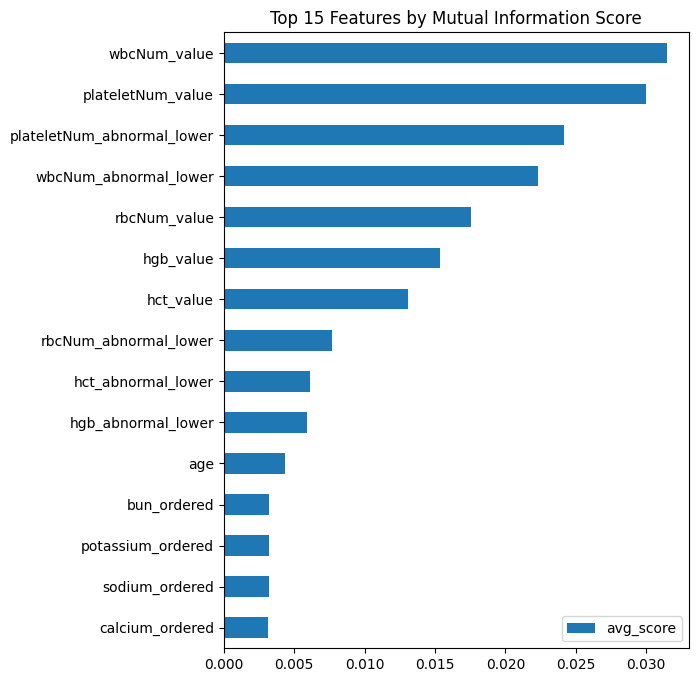

In [67]:
# Mutual information for binary features
mi_scores_binary = simulate_mi_scores(
    complete_df
    , 'has_pancytopenia'
    , binary_features
    , n_simulations=50
    , is_binary=True
)

# Mutual information for continuous features
mi_scores_continuous = simulate_mi_scores(
    complete_df
    , 'has_pancytopenia'
    , continuous_features
    , n_simulations=50
    , is_binary=False
)

# Union mutual information scores for binary and continuous features
mi_scores = pd.concat([mi_scores_binary, mi_scores_continuous])
mi_scores = mi_scores.sort_values('avg_score', ascending=False)

# Plot the top features by mutual information score
(
    mi_scores
    .head(15)
    .sort_values('avg_score')
    .plot(kind='barh', y='avg_score', figsize=(6, 8), title='Top 15 Features by Mutual Information Score')
)
plt.show()

## Top features

In [68]:
# Top features by mutual information score that are not highly correlated with any other feature (correlation > 0.95)
top_n_features = 20
top_features = (
    mi_scores
    .drop(index=high_corr_features)
    .head(top_n_features)
    .index.tolist()
)
print(f'Top {top_n_features} features:', *top_features, sep="\n- ")

Top 20 features:
- wbcNum_value
- plateletNum_value
- plateletNum_abnormal_lower
- wbcNum_abnormal_lower
- rbcNum_value
- hgb_value
- rbcNum_abnormal_lower
- hct_abnormal_lower
- hgb_abnormal_lower
- age
- bun_ordered
- chlordiazepoxide
- ibuprofen
- lactulose
- calcium_abnormal_lower
- glucose_ordered
- thiamine
- docusate
- diazepam
- gender


# Model selection

In [69]:
X = complete_df[top_features]
y = complete_df['has_pancytopenia']
print('X:', X.shape)
print('y:', y.shape)

X: (10261, 20)
y: (10261,)


## Class weights

In [70]:
y.value_counts()

has_pancytopenia
0    10080
1      181
Name: count, dtype: int64

In [71]:
# Calculate class weights
class_weights = compute_class_weight(
    'balanced'
    , classes=np.unique(y)
    , y=y
)
class_weight_dict = dict(zip(np.unique(y), class_weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.5089781746031746), np.int64(1): np.float64(28.345303867403317)}


In [72]:
# List of models to compare, all with class weights to address class imbalance.
models = {
    'Random Forest (Balanced)': RandomForestClassifier(
        n_estimators=100
        , class_weight=class_weight_dict
        , random_state=1234
    ),
    'Logistic Regression (Balanced)': LogisticRegression(
        class_weight=class_weight_dict
        , solver='liblinear'
        , random_state=1234
    ),
    'XGBoost (Balanced)': XGBClassifier(
        scale_pos_weight=class_weights[0]/class_weights[1]
        , random_state=1234
    )
}

# Define multiple scoring metrics
scoring = {
    'roc_auc': 'roc_auc'
    , 'average_precision': 'average_precision'  # PR-AUC
}

# Compare models using cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
results = {}

for name, model in models.items():
    cv_scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    
    results[name] = {
        'mean_roc_auc': cv_scores['test_roc_auc'].mean()
        , 'std_roc_auc': cv_scores['test_roc_auc'].std()
        
        , 'mean_pr_auc': cv_scores['test_average_precision'].mean()
        , 'std_pr_auc': cv_scores['test_average_precision'].std()
        
        , 'cv_scores': cv_scores
    }
    
    print(f"\n{name}:")
    print(f"  ROC AUC: {cv_scores['test_roc_auc'].mean():.4f} (+/- {cv_scores['test_roc_auc'].std() * 2:.4f})")
    print(f"  PR AUC:  {cv_scores['test_average_precision'].mean():.4f} (+/- {cv_scores['test_average_precision'].std() * 2:.4f})")


Random Forest (Balanced):
  ROC AUC: 0.9320 (+/- 0.0458)
  PR AUC:  0.4912 (+/- 0.1969)

Logistic Regression (Balanced):
  ROC AUC: 0.9599 (+/- 0.0207)
  PR AUC:  0.4990 (+/- 0.1447)

XGBoost (Balanced):
  ROC AUC: 0.9470 (+/- 0.0279)
  PR AUC:  0.5599 (+/- 0.1813)


## Hyperparameter tuning for XGBoost

In [73]:
# # XGBoost hyperparameter tuning with expanded parameter grid
# xgb_param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [3, 4, 5, 6],
#     'learning_rate': [0.01, 0.05, 0.1, 0.15],
#     'subsample': [0.8, 0.9, 1.0],
#     'colsample_bytree': [0.8, 0.9, 1.0],
#     'scale_pos_weight': [class_weights[0]/class_weights[1]] # Keep the class weight
# }

# # Initialize XGBoost classifier
# xgb_model = XGBClassifier(random_state=1234)

# # Grid search with cross-validation
# xgb_grid_search = GridSearchCV(
#     estimator=xgb_model,
#     param_grid=xgb_param_grid,
#     cv=cv,
#     scoring='average_precision', # Optimize for PR AUC
#     n_jobs=-1,
#     verbose=1
# )

# # Fit the grid search
# print("Starting XGBoost hyperparameter tuning...")
# xgb_grid_search.fit(X, y)

# # Print results
# print(f"\nBest XGBoost parameters: {xgb_grid_search.best_params_}")
# print(f"Best cross-validation PR AUC: {xgb_grid_search.best_score_:.4f}")

# # Get the best model
# best_xgb_model = xgb_grid_search.best_estimator_

# # Evaluate the best model
# best_cv_scores = cross_validate(best_xgb_model, X, y, cv=cv, scoring=scoring)
# print(f"\nBest XGBoost model performance:")
# print(f"ROC AUC: {best_cv_scores['test_roc_auc'].mean():.4f} (+/- {best_cv_scores['test_roc_auc'].std() * 2:.4f})")
# print(f"PR AUC:  {best_cv_scores['test_average_precision'].mean():.4f} (+/- {best_cv_scores['test_average_precision'].std() * 2:.4f})")

In [74]:
# Best parameters from grid search
best_xgb_model = XGBClassifier(
        random_state=1234
        , scale_pos_weight=class_weights[0]/class_weights[1]
        , colsample_bytree=0.9
        , learning_rate=0.1
        , max_depth=3
        , n_estimators=200
        , subsample=0.9
)

best_cv_scores = cross_validate(best_xgb_model, X, y, cv=cv, scoring=scoring)
print(f"\nBest XGBoost model performance:")
print(f"ROC AUC: {best_cv_scores['test_roc_auc'].mean():.4f} (+/- {best_cv_scores['test_roc_auc'].std() * 2:.4f})")
print(f"PR AUC:  {best_cv_scores['test_average_precision'].mean():.4f} (+/- {best_cv_scores['test_average_precision'].std() * 2:.4f})")


Best XGBoost model performance:
ROC AUC: 0.9503 (+/- 0.0257)
PR AUC:  0.5623 (+/- 0.1806)


## Decision threshold / ranking threshold

Predicted probability statistics:
Min: 0.000029
Max: 0.198938
Mean: 0.000838
Median: 0.000048
25th percentile: 0.000037
75th percentile: 0.000112

Probabilities by actual class:
Positive class (pancytopenia) - Mean: 0.028115, Median: 0.007718
Negative class (no pancytopenia) - Mean: 0.000348, Median: 0.000048



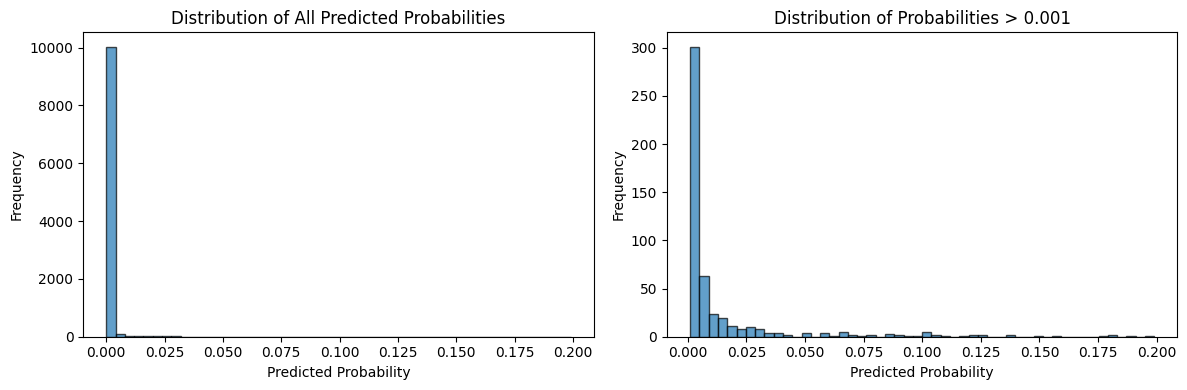

In [75]:
# Get cross-validated predictions
y_pred_proba = cross_val_predict(best_xgb_model, X, y, cv=cv, method='predict_proba')[:, 1]

# Distribution of predicted probabilities
print("Predicted probability statistics:")
print(f"Min: {y_pred_proba.min():.6f}")
print(f"Max: {y_pred_proba.max():.6f}")
print(f"Mean: {y_pred_proba.mean():.6f}")
print(f"Median: {np.median(y_pred_proba):.6f}")
print(f"25th percentile: {np.percentile(y_pred_proba, 25):.6f}")
print(f"75th percentile: {np.percentile(y_pred_proba, 75):.6f}")

# Check by actual class
print(f"\nProbabilities by actual class:")
print(f"Positive class (pancytopenia) - Mean: {y_pred_proba[y==1].mean():.6f}, Median: {np.median(y_pred_proba[y==1]):.6f}")
print(f"Negative class (no pancytopenia) - Mean: {y_pred_proba[y==0].mean():.6f}, Median: {np.median(y_pred_proba[y==0]):.6f}\n")

# Plot distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(y_pred_proba, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Distribution of All Predicted Probabilities')

plt.subplot(1, 2, 2)
plt.hist(y_pred_proba[y_pred_proba > 0.001], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Probabilities > 0.001')
plt.tight_layout()
plt.show()

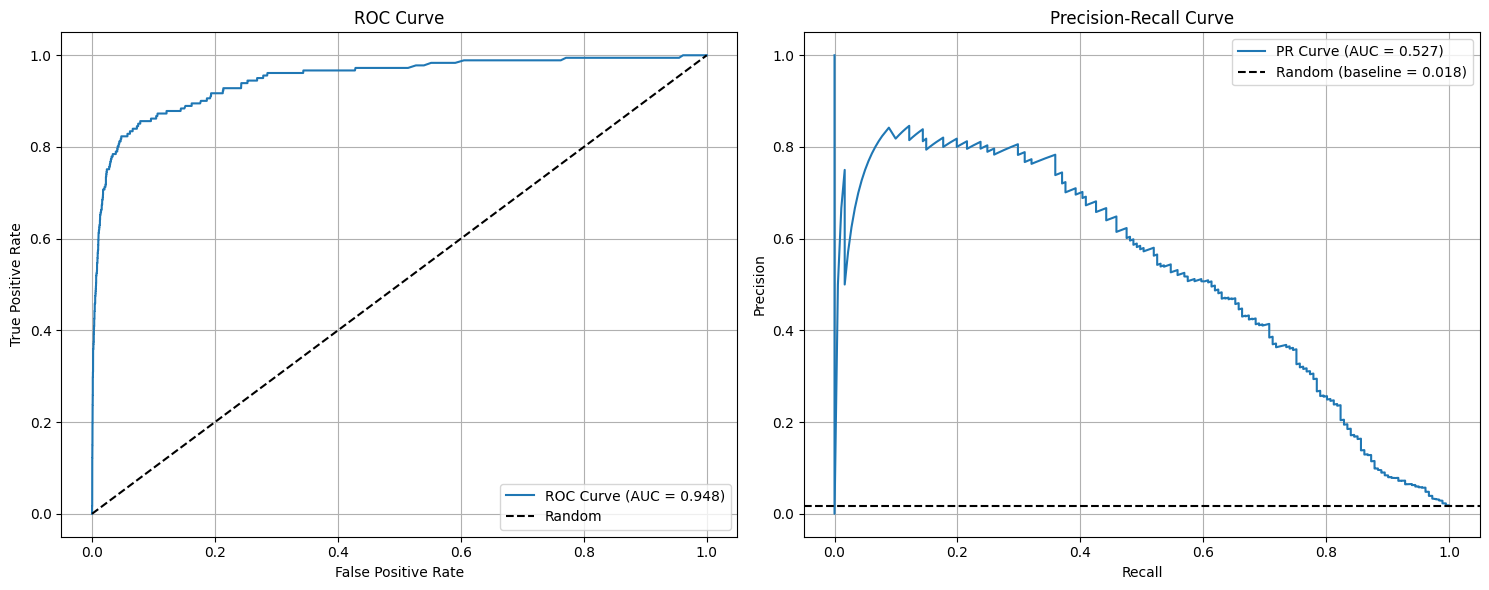

In [76]:
# ROC Curve
    # True positive rate (recall) vs false positive rate (1 - recall) at different classification thresholds.
    # ROC-AUC=0.948, which indicates strong ability to discriminate between patients with and without Pancytopenia across all thresholds.
    # The model has good ability to rank patients by risk - it can distinguish between those who will/won't develop Pancytopenia.
fpr, tpr, thresholds_roc = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

# PR Curve
    # Precision vs recall at different classification thresholds.
    # PR-AUC=0.528, which is more modest and reflects the challenge of achieving high precision (low false positive rate) while maintaining good recall (sensitivity) in this imbalanced dataset.
    # When the model predicts high risk, it's moderately precise. Important when false positives have costs.
precision, recall, thresholds_pr = precision_recall_curve(y, y_pred_proba)
pr_auc = auc(recall, precision)

# Plot both curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
ax1.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()
ax1.grid(True)

# PR Curve
ax2.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})')
ax2.axhline(y=y.mean(), color='k', linestyle='--', label=f'Random (baseline = {y.mean():.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [77]:
# Use percentile-based threshold instead of absolute probability
# Find threshold that captures top X% of risk scores

percentile_thresholds = [90, 95, 99]  # Top 10%, 5%, 1% of patients

for pct in percentile_thresholds:
    threshold_pct = np.percentile(y_pred_proba, pct)
    y_pred_pct = (y_pred_proba >= threshold_pct).astype(int)
    
    precision_pct = precision_score(y, y_pred_pct, zero_division=0)
    recall_pct = recall_score(y, y_pred_pct, zero_division=0)
    f1_pct = f1_score(y, y_pred_pct, zero_division=0)
    
    print(f"\nTop {100-pct}% threshold ({threshold_pct:.6f}):")
    print(f"  Precision: {precision_pct:.3f}")
    print(f"  Recall: {recall_pct:.3f}")
    print(f"  F1: {f1_pct:.3f}")
    print(f"  Patients flagged: {y_pred_pct.sum()}/{len(y)} ({y_pred_pct.mean():.1%})")


Top 10% threshold (0.000296):
  Precision: 0.151
  Recall: 0.856
  F1: 0.257
  Patients flagged: 1027/10261 (10.0%)

Top 5% threshold (0.000955):
  Precision: 0.276
  Recall: 0.785
  F1: 0.409
  Patients flagged: 514/10261 (5.0%)

Top 1% threshold (0.014890):
  Precision: 0.699
  Recall: 0.398
  F1: 0.507
  Patients flagged: 103/10261 (1.0%)


In [78]:
# Start with top 5% threshold
    # Good balance of precision (27.8%) and recall (79.0%)
    # Manageable patient load (514 patients)
    # Catches most pancytopenia cases while limiting false positives

chosen_threshold = 0.000954
fit_model = best_xgb_model.fit(X, y)
probabilities = fit_model.predict_proba(X)[:, 1]
high_risk_flags = (probabilities >= chosen_threshold).astype(int)

print(f"Using threshold {chosen_threshold:.6f}:")
print(f"Patients flagged as high-risk: {high_risk_flags.sum()} ({high_risk_flags.mean():.1%})")

Using threshold 0.000954:
Patients flagged as high-risk: 483 (4.7%)


# Feature importance

## SHAP

In [79]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X)

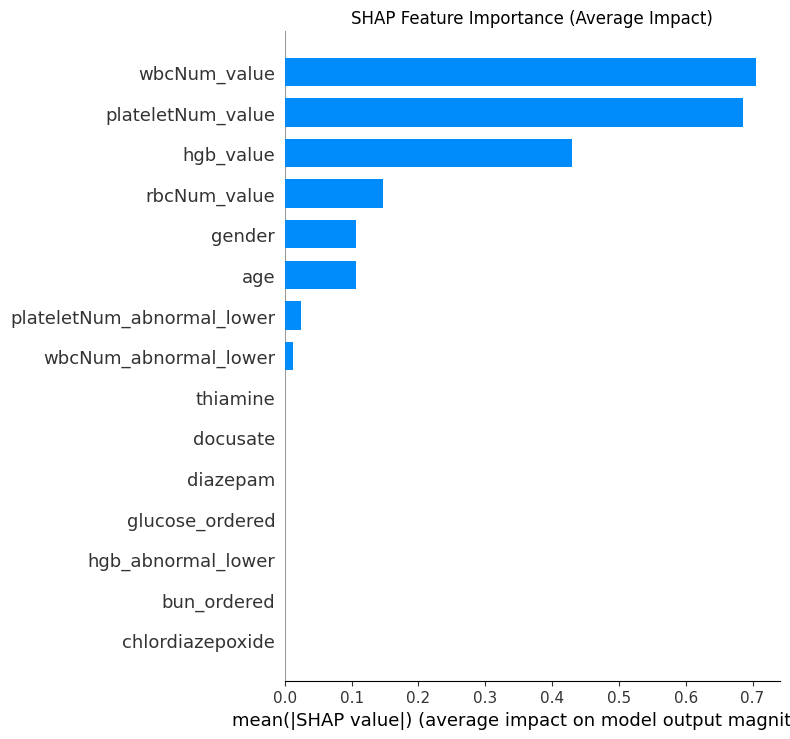

In [80]:
# Summary plot - shows feature importance and impact direction
shap.summary_plot(shap_values, X, plot_type="bar", show=False, max_display=15)
plt.title('SHAP Feature Importance (Average Impact)')
plt.tight_layout()
plt.show()

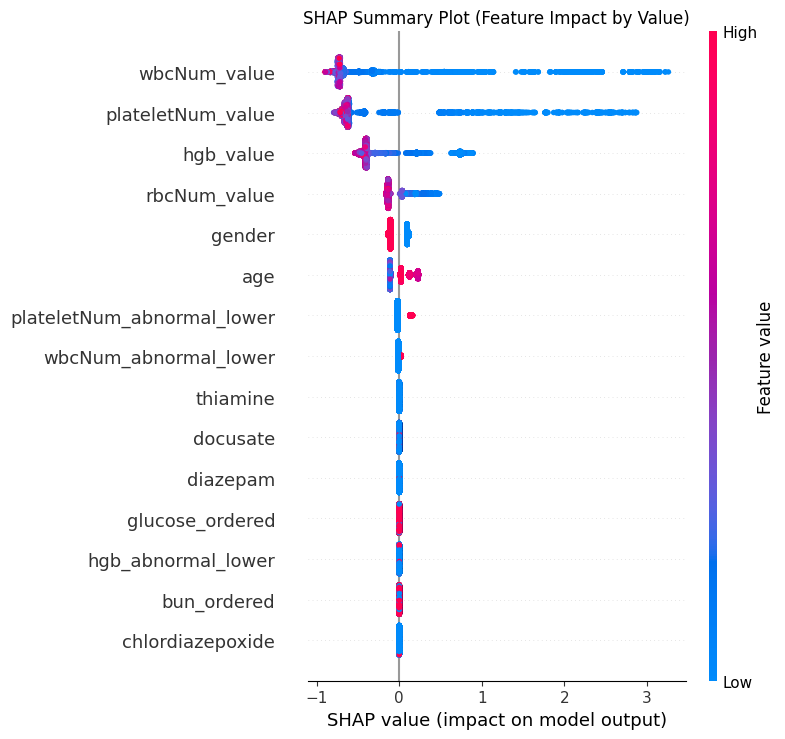

In [81]:
# Detailed SHAP summary plot - shows how feature values affect predictions
shap.summary_plot(shap_values, X, show=False, max_display=15)
plt.title('SHAP Summary Plot (Feature Impact by Value)')
plt.tight_layout()
plt.show()

In [82]:
# Feature importance dataframe
shap_importance = pd.DataFrame({
    'feature': X.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("Top 10 Features by SHAP Importance:")
print(shap_importance.head(10))

Top 10 Features by SHAP Importance:
                       feature  shap_importance
0                 wbcNum_value         0.705865
1            plateletNum_value         0.686267
5                    hgb_value         0.429457
4                 rbcNum_value         0.146322
19                      gender         0.107077
9                          age         0.107077
2   plateletNum_abnormal_lower         0.024641
3        wbcNum_abnormal_lower         0.011879
7           hct_abnormal_lower         0.000000
8           hgb_abnormal_lower         0.000000


## Permutation importance

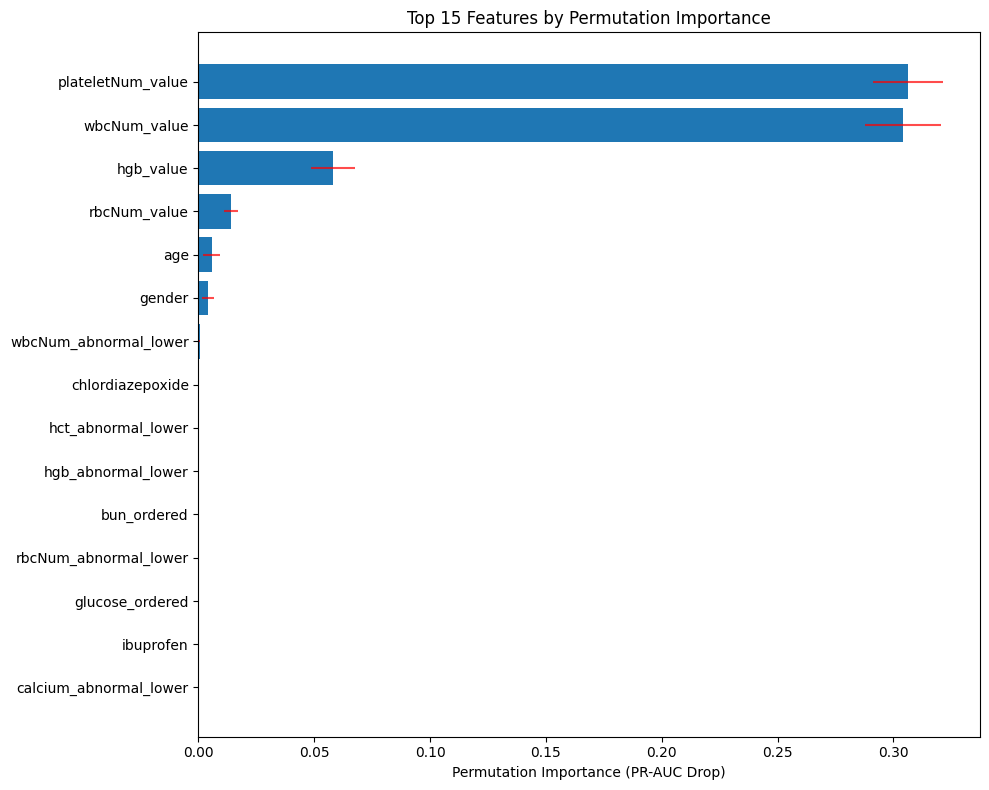

Top 10 Features by Permutation Importance:
                  feature  importance_mean  importance_std
1       plateletNum_value         0.306308        0.014982
0            wbcNum_value         0.304192        0.016420
5               hgb_value         0.058161        0.009490
4            rbcNum_value         0.013956        0.003038
9                     age         0.005694        0.003654
19                 gender         0.004085        0.002774
3   wbcNum_abnormal_lower         0.000541        0.000119
11       chlordiazepoxide         0.000000        0.000000
7      hct_abnormal_lower         0.000000        0.000000
8      hgb_abnormal_lower         0.000000        0.000000


In [83]:
# Calculate permutation importance using cross-validation
perm_importance = permutation_importance(
    best_xgb_model, X, y, 
    scoring='average_precision',  # Use PR-AUC since that's what we care about
    n_repeats=10, 
    random_state=1234,
    n_jobs=-1
)

# Create dataframe
perm_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
top_perm = perm_importance_df.head(15)
plt.barh(range(len(top_perm)), top_perm['importance_mean'])
plt.errorbar(top_perm['importance_mean'], range(len(top_perm)), 
             xerr=top_perm['importance_std'], fmt='none', color='red', alpha=0.7)
plt.yticks(range(len(top_perm)), top_perm['feature'])
plt.xlabel('Permutation Importance (PR-AUC Drop)')
plt.title('Top 15 Features by Permutation Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Features by Permutation Importance:")
print(perm_importance_df.head(10))